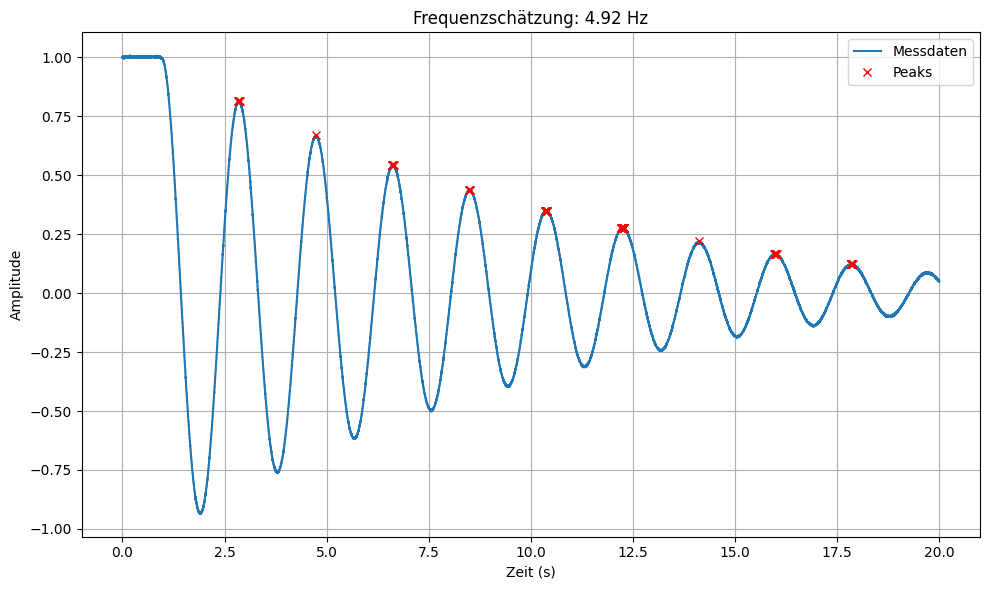

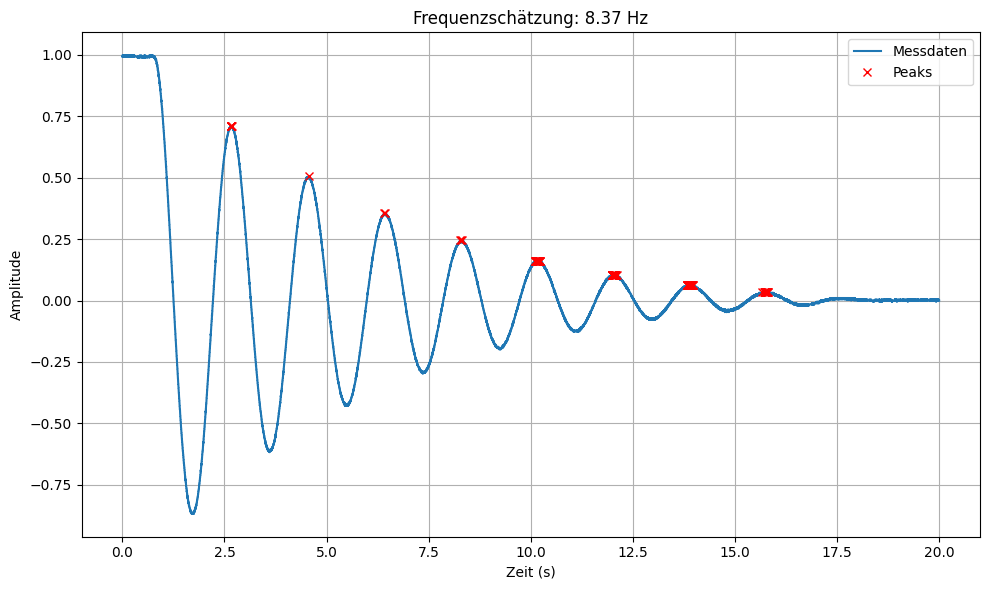

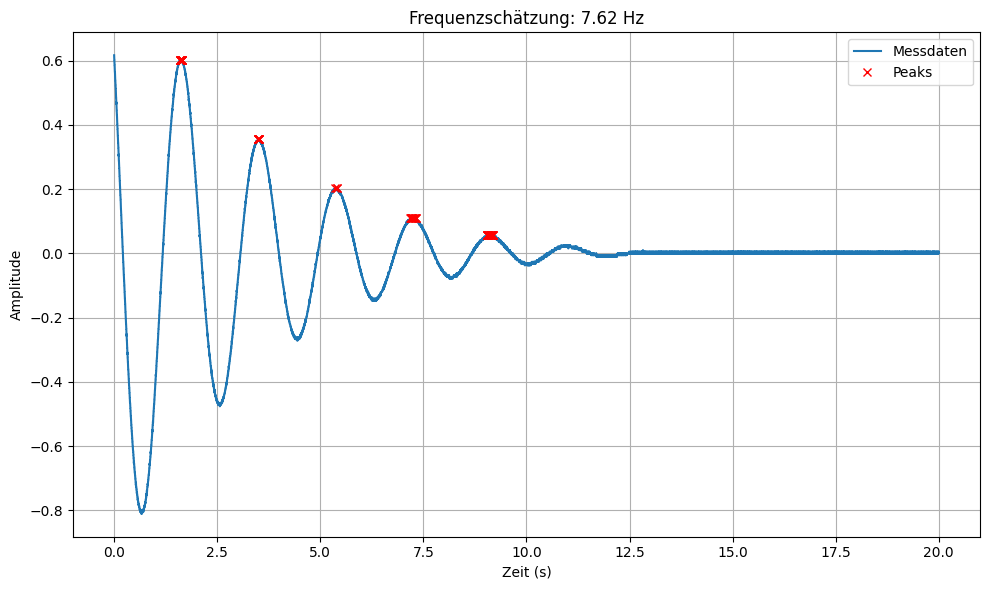

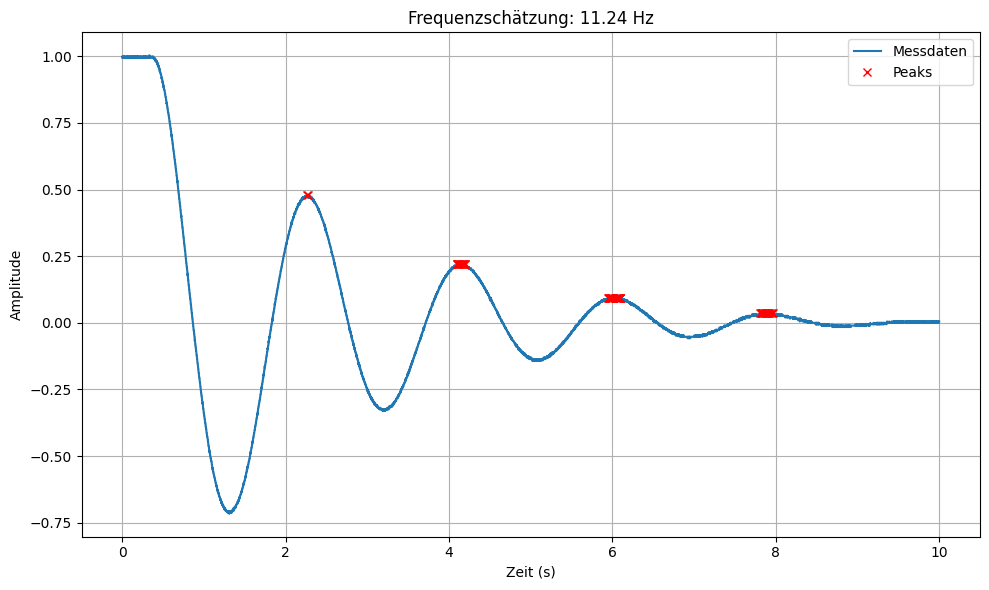

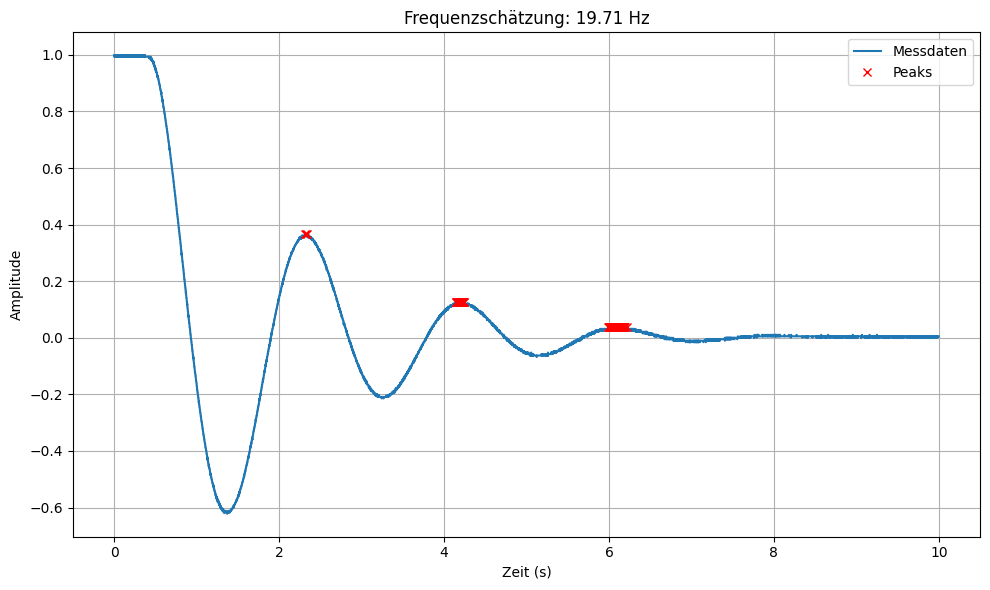

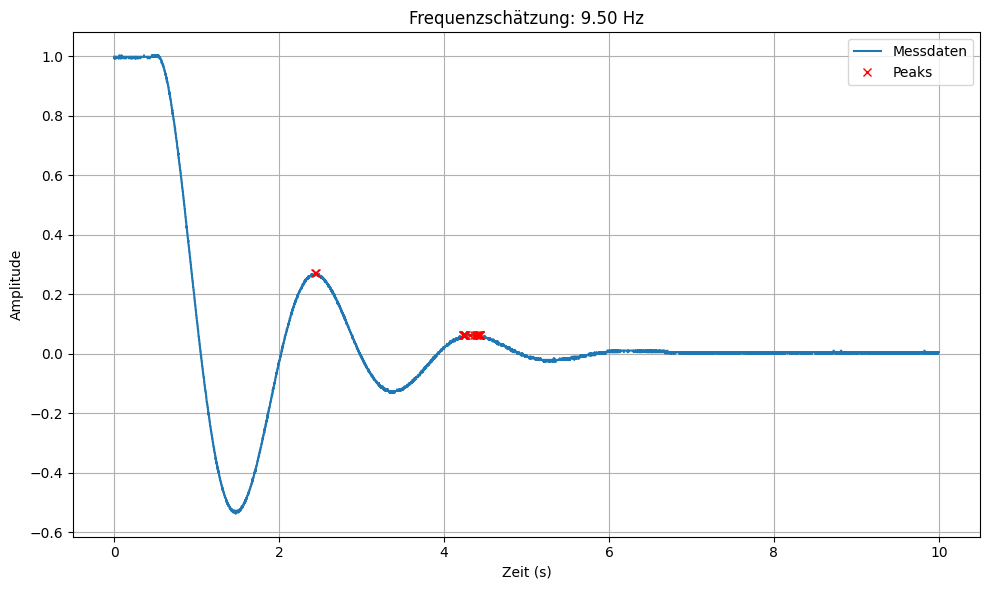

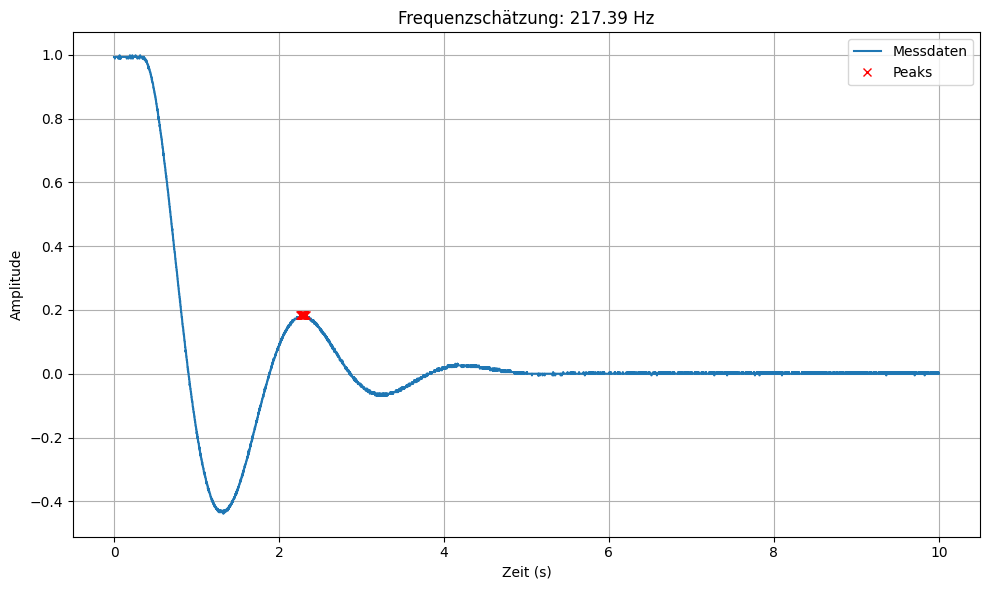

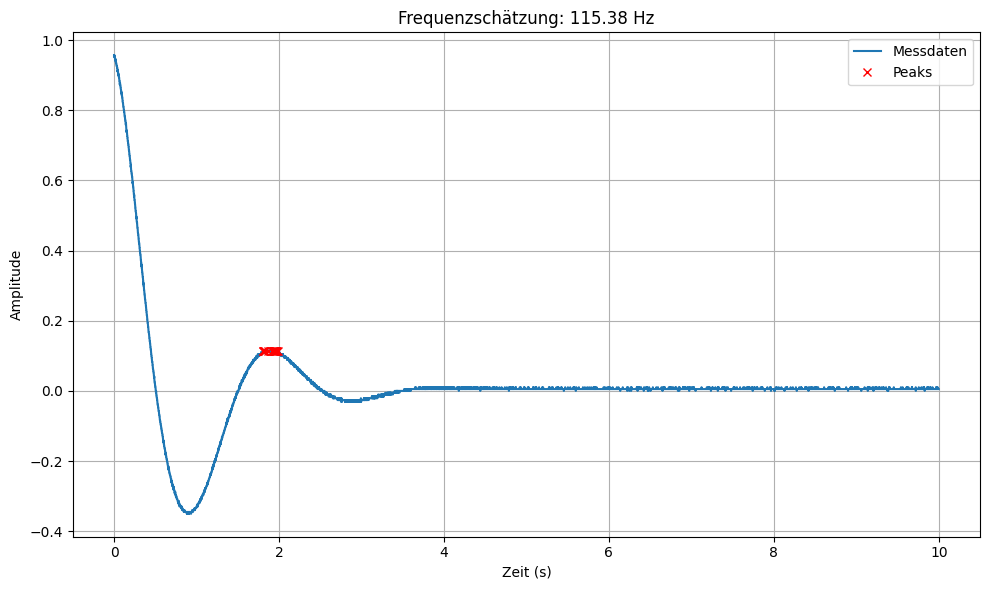

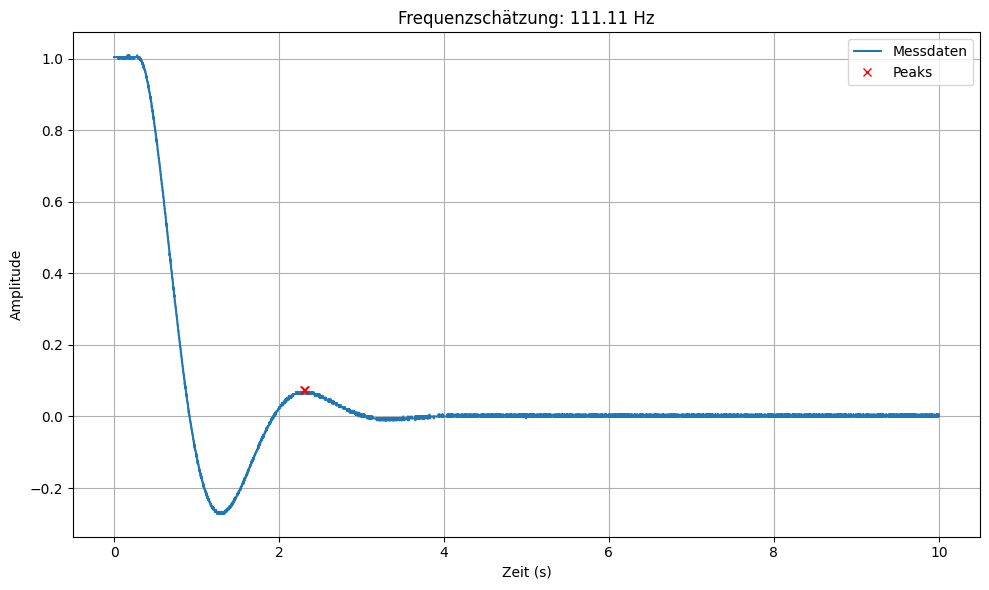

Nicht genug Peaks gefunden.


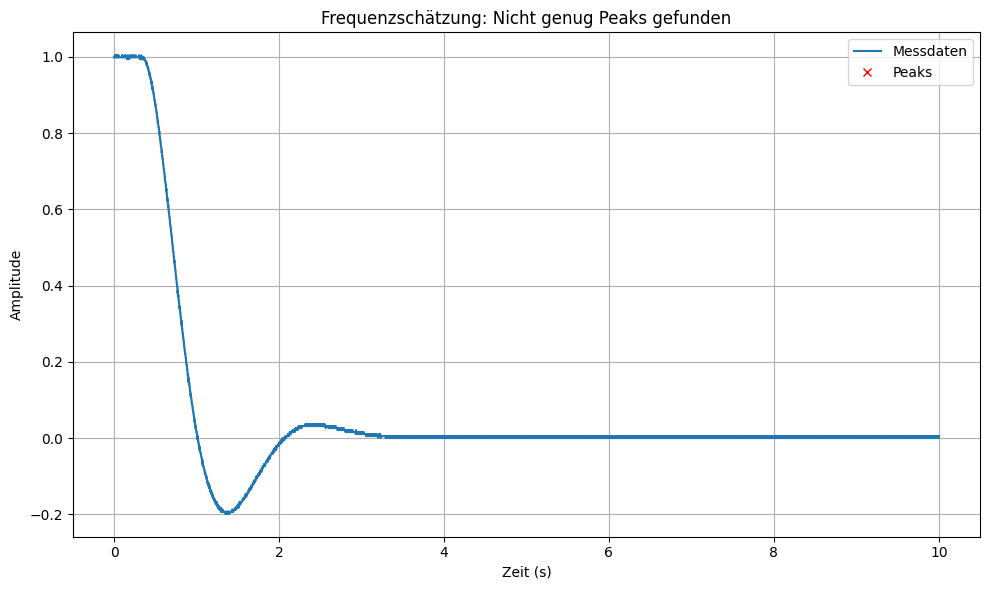

[0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2]
[0.10043302 0.22370615 0.3039659  0.44153997 0.59871192]
[3.25596782 3.18238938 3.32744702 3.23916527 3.12143654 2.87320799
 3.00239735 3.13527212 2.84382818 2.59315713]
[np.float64(4.916290193994154) np.float64(8.365655182903643)
 np.float64(7.622552240767512) np.float64(11.237928007023704)
 np.float64(19.713261648745522)]


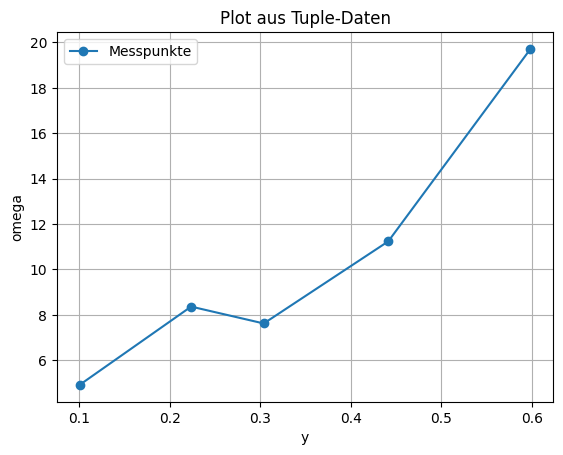

In [28]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
from natsort import natsorted
import re
from scipy.signal import find_peaks


def extract_numeric_prefix(filename):
    match = re.match(r"(\d+)_(\d+)", filename)
    if match:
        integer_part = match.group(1)
        decimal_part = match.group(2)
        return float(f"{integer_part}.{decimal_part}")
    return None


def damped_sinus_function(x, A, delta, omega, phase, offset):
    return A * np.exp(-delta * x) * np.sin(omega * x + phase) + offset

def estimate_frequency_from_peaks(t, y, prominence=0.05):
    # Finde die Peaks mit definierter Mindestprominenz (Rauschunterdrückung)
    peaks, _ = find_peaks(y, prominence=prominence)
    
    # Wenn weniger als 2 Peaks, Frequenzberechnung nicht möglich
    if len(peaks) < 2:
        print("Nicht genug Peaks gefunden.")
        return None, peaks

    # Zeiten der Peaks
    peak_times = t[peaks]
    
    # Perioden berechnen (Zeitdifferenzen zwischen Peaks)
    periods = np.diff(peak_times)
    
    # Durchschnittliche Periodendauer
    avg_period = np.mean(periods)
    
    # Frequenz in Hz
    frequency = 1 / avg_period
    return frequency, peaks

# Schätzfunktion für omega aus FFT
def estimate_omega_fft(x_data, y_data):
    dt = np.mean(np.diff(x_data))
    n = len(x_data)
    f = np.fft.fftfreq(n, d=dt)
    Y = np.fft.fft(y_data - np.mean(y_data))
    idx = np.argmax(np.abs(Y[1:n//2])) + 1  # überspringe 0-Frequenz
    freq = np.abs(f[idx])
    omega = 2 * np.pi * freq
    return omega

# Sinus fitten
def fit_damped_sinus(x_data, y_data):
    A_guess = (np.max(y_data) - np.min(y_data)) / 2
    omega_guess = estimate_omega_fft(x_data, y_data)
    delta_guess = 0.1  # Startwert für Dämpfung
    phase_guess = 0
    offset_guess = np.mean(y_data)
    p0 = [A_guess, delta_guess, omega_guess, phase_guess, offset_guess]
    
    params, params_covariance = curve_fit(
        damped_sinus_function, x_data, y_data, p0=p0, maxfev=10000
    )
    
    fitted_y = damped_sinus_function(x_data, *params)
    return params, fitted_y


# Ordnerpfad anpassen
filepath = "M10_Aufgabe_1_CSV_Daten"

# Alle CSV-Dateien holen und sortieren
csv_files = [f for f in os.listdir(filepath) if f.endswith('.csv')]
csv_files = natsorted(csv_files)

# Listen für Amplituden und Omegas
amplitudes_U1 = []
omegas_U1 = []
tuple_delta_file = []
frequency = []
for filename in csv_files:
    df = pd.read_csv(os.path.join(filepath, filename))
    df = df[['t (s)', 'U1(V)']]  # Keep only the required columns

    x = df['t (s)'].values
    y = df['U1(V)'].values

    # Zeit- und Messdaten extrahieren
    t = df.iloc[:, 0].values
    z = df.iloc[:, 1].values
    frequency_wert, peaks = estimate_frequency_from_peaks(t, y)

    paramsU1, fitted_U1 = fit_damped_sinus(x, y)

    Strom = extract_numeric_prefix(filename)

    if Strom is not None:
        tuple_delta_file.append((Strom, paramsU1[1]))
    
    # Speichere absolute Amplitude (ohne Offset)
    amplitudes_U1.append(np.abs(paramsU1[0]))
    omegas_U1.append(paramsU1[2])

    frequency.append(frequency_wert)
    plt.figure(figsize=(10, 6))
    plt.plot(t, y, label="Messdaten")
    plt.plot(t[peaks], y[peaks], "rx", label="Peaks")
    if frequency_wert is not None:
        plt.title(f"Frequenzschätzung: {frequency_wert:.2f} Hz")
    else:
        plt.title("Frequenzschätzung: Nicht genug Peaks gefunden")
    plt.xlabel("Zeit (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    #print(f"File: {filename}")
    #print(f"Amplitude: {np.abs(paramsU1[0])}, Omega: {paramsU1[2]}, Delta: {paramsU1[1]}, Phase: {paramsU1[3]}, Offset: {paramsU1[4]}")

    #plt.figure(figsize=(10, 6))
    #plt.plot(x, y, 'o', label='U1 data')
    #plt.plot(x, fitted_U1, '--', label='U1 fit')
    #plt.xlabel('t (s)')
    #plt.ylabel('Auslenkung')
    #plt.title(filename)
    #plt.legend()
    #plt.grid(True)
    #plt.tight_layout()
    #plt.show()

#print("Tuple (Strom, Delta):")
#for item in tuple_delta_file:
#    print(item)
 
# Unpack the tuples into two separate lists
x_values, y_values = zip(*tuple_delta_file)
Strom_array = np.array(x_values)
Delta = np.array(y_values)
omegas_U1 = np.array(omegas_U1)
frequency = np.array(frequency)
frequency = frequency[0:5]
Delta = Delta[0:5]

print(Strom_array)
print(Delta)
print(omegas_U1)
print(frequency)

# Plot
plt.plot(Delta, frequency, 'o-', label='Messpunkte')
plt.xlabel('y')
plt.ylabel('omega')
plt.title('Plot aus Tuple-Daten')
plt.grid(True)
plt.legend()
plt.show()
